In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()

TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

api_key = os.getenv('gemini_api_key')

from langchain.chat_models import init_chat_model
llm = init_chat_model(
    "gemini-3.1-flash-lite", 
    model_provider="google_genai",
    api_key=api_key, # 🔑 Right here! Passing it explicitly to the model configuration
    temperature=1.0 
)



c:\DEV\devilcode development\Langchain-part2\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


### here we will be creating the tavily tool , copy paste from docs 

In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [1]:
response = tavily_tool.invoke("What is the todays tweet of Doland Trump , president of USA ? , te day today is 9 october 2026")


NameError: name 'tavily_tool' is not defined

In [12]:
response

{'query': 'What is the todays tweet of Doland Trump , president of USA ? , te day today is 9 october 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://rollcall.com/factbase/trump/topic/social',
   'title': 'factbase twitter',
   'content': "Donald Trump\n\n@realDonaldTrump• Deleted•Image 41: Truth Social iconImage 42: Truth Social iconTruth Social•September 28, 2026 @ 8:02 AM ET\n\nView ImageView on X\n\nImage 43: Truth Social iconView ImageView on Truth Social\n\nImage 44: Truth Social iconView ImageView on Truth SocialView on Truth Social\n\nJoe Scarborough’s show has been cut way back, and will soon be “dead!” Too predictable and boring! REALLY BAD RATINGS, just like the rest of MSNOW (MSDNC!). President DJT\n\nImage 45 [...] RT @realDonaldTrumpMore people working in the United States right now than at any point in the History of our Country! President DJT\n\nImage 349\n\nImage 350: Media from Donald Trump's post\n\nImage 351Image 352

#### creating a calculator tool 

In [5]:
from langchain.tools import tool

@tool(
    "calculator",
    description="A calculator tool that can be used to perform mathematical calculations. It takes a mathematical expression as input and returns the result of the calculation."
)
def calculator(expression: str) -> str:
    """It takes a mathematical expression as input and returns the result of the calculation."""
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

### Now we will create the agent to use these tools 

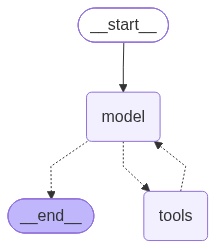

In [6]:
from langchain.agents import create_agent

agent = create_agent(
    model = llm,
    tools=[tavily_tool , calculator ],
    system_prompt="You are a helpful ai "
    )

agent

## Now we will create the Real Engine 

Here is a breakdown of what each part is doing:

1. agent.stream(...)
Instead of waiting for the AI to finish its entire research process (which could take several seconds), stream allows you to see the output as it happens.

{"messages": user_input}: You are passing your question to the agent. In LangChain, agents usually expect a list of messages (the history of the conversation) to understand context.

stream_mode="values": This tells LangChain to give you the full state of the agent at every single step. If the agent decides to use Tavily, then reads the results, and then finally answers, this loop will run multiple times—once for each "event."

2. for step in ...
Because you are streaming, the code enters a loop. Each step represents a new piece of information the agent has generated.

First step: The agent acknowledges your question.

Middle steps: The agent decides to use a tool (like Tavily) and shows the raw data it found.

Final step: The agent provides the human-readable answer.

3. step["messages"][-1]
In "values" mode, each step contains the entire history of the conversation.

step["messages"] is the list of all messages sent and received so far.

[-1] is Python shorthand for "get the very last item." This ensures you are only looking at the newest piece of information (the most recent thought or tool result) rather than re-printing the whole conversation over and over.

4. .pretty_print()
This is a built-in LangChain helper function. Instead of showing you a messy block of code/JSON, it formats the output so it’s easy for a human to read in the console.

It will label the output clearly as a Human Message, Tool Call, or AI Message.

It often uses colors to distinguish who is "talking.

In [9]:
from langchain_core.messages import HumanMessage

user_input = "What is the current news related to anthropic . And then Calculate 5 * pi * pi * 7 *7 "


for step in agent.stream(
    input={"messages": [HumanMessage(content=user_input)]},
    stream_mode="values",
):
    step["messages"][-1]

In [11]:
print("Final Response: ", step["messages"][-1].content)

Final Response:  [{'type': 'text', 'text': 'Recent news regarding Anthropic (as of October 2026) includes the following developments:\n\n*   **Cybersecurity Initiatives:** Anthropic has expanded its **Cyber Verification Program (CVP)** to provide vetted security professionals with access to advanced models with reduced safety blocking, aimed at defensive work and infrastructure testing. This follows the success of "Project Glasswing," which the company reported helped identify over 129,000 software vulnerabilities.\n*   **Model Development:** The company recently announced that its AI model, Claude, is being used to actively assist in the research and development of its own successor. Anthropic noted that about 90% of its R&D work involves collaboration with Claude.\n*   **Policy Updates:** Anthropic updated its usage policy to include stricter prohibitions against election interference, surveillance, and weapons software. Notably, the policy now also explicitly forbids "prolonged verb